<a href="https://colab.research.google.com/github/gowripreetham/SJSU_Deep_Learning_neural-network-using-numpy-keras-pytorch/blob/main/colab_d_pytorch_lightning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Colab D — 3-Layer Neural Network: PyTorch Lightning

**Assignment:** Refactor the Colab C model into **PyTorch Lightning** — the standard framework for production-grade PyTorch training.

---

## What PyTorch Lightning adds vs plain PyTorch:
| Concern | Colab C (raw) | Colab D (Lightning) |
|---|---|---|
| Training loop | Manually written | `trainer.fit()` handles it |
| Logging | `print()` statements | `self.log()` → TensorBoard |
| Checkpointing | Manual | Built-in callbacks |
| GPU/CPU | `tensor.to(DEVICE)` | Automatic |
| Validation | Manually written | `validation_step()` hook |

In [1]:
# ─────────────────────────────────────────────
# SECTION 1: Install & Imports
# ─────────────────────────────────────────────
!pip install lightning -q

import torch
import torch.nn as nn
import lightning as L
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_absolute_error

torch.manual_seed(42)
np.random.seed(42)
print(f'Lightning version: {L.__version__}')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 853.6/853.6 kB 18.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 31.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 857.3/857.3 kB 29.0 MB/s eta 0:00:00
Lightning version: 2.6.1


In [2]:
# ─────────────────────────────────────────────
# SECTION 2: Data (same equation)
# ─────────────────────────────────────────────

def generate_data(n=2000):
    x1 = np.random.uniform(-np.pi, np.pi, n)
    x2 = np.random.uniform(-np.pi, np.pi, n)
    x3 = np.random.uniform(-2, 2, n)
    noise = np.random.normal(0, 0.05, n)
    y = np.sin(x1)*np.cos(x2) + x3**2 + 0.5*np.sin(x1*x3) + noise
    X = np.stack([x1, x2, x3], axis=1).astype(np.float32)
    return X, y.reshape(-1, 1).astype(np.float32)

X_np, y_np = generate_data()
X_mean, X_std = X_np.mean(0), X_np.std(0)
y_mean, y_std = y_np.mean(), y_np.std()
X_np = (X_np - X_mean) / X_std
y_np = (y_np - y_mean) / y_std

split = int(0.8 * len(X_np))
X_tr, X_te = X_np[:split], X_np[split:]
y_tr, y_te = y_np[:split], y_np[split:]
print(f'Train: {X_tr.shape}  Test: {X_te.shape}')

Train: (1600, 3)  Test: (400, 3)


## Section 3: LightningDataModule

Encapsulates all data loading logic — clean separation of data from model.

In [3]:
# ─────────────────────────────────────────────
# SECTION 3: LightningDataModule
# ─────────────────────────────────────────────

class RegressionDataModule(L.LightningDataModule):
    """DataModule wraps all data loading logic.

    Lightning calls .train_dataloader() and .val_dataloader()
    automatically at the right times.
    """
    def __init__(self, X_train, y_train, X_val, y_val, batch_size=64):
        super().__init__()
        self.X_train = torch.from_numpy(X_train)
        self.y_train = torch.from_numpy(y_train)
        self.X_val   = torch.from_numpy(X_val)
        self.y_val   = torch.from_numpy(y_val)
        self.batch_size = batch_size

    def train_dataloader(self):
        ds = TensorDataset(self.X_train, self.y_train)
        return DataLoader(ds, batch_size=self.batch_size, shuffle=True, num_workers=0)

    def val_dataloader(self):
        ds = TensorDataset(self.X_val, self.y_val)
        return DataLoader(ds, batch_size=256, num_workers=0)

dm = RegressionDataModule(X_tr, y_tr, X_te, y_te, batch_size=64)
print('DataModule ready.')

DataModule ready.


## Section 4: LightningModule

The `LightningModule` combines the model architecture + training/validation logic.  
Key hooks:
- `training_step()` — one forward pass + loss (called per batch)
- `validation_step()` — evaluation pass (no grad)
- `configure_optimizers()` — returns optimizer + scheduler

In [4]:
# ─────────────────────────────────────────────
# SECTION 4: LightningModule
# ─────────────────────────────────────────────

class DeepNetLightning(L.LightningModule):
    """3-layer deep network as a LightningModule.

    Architecture: 3 → 64 → 32 → 1

    Lightning automatically:
    - Calls training_step() for each batch
    - Calls validation_step() on val data
    - Handles optimizer.zero_grad() + backward() + step()
    - Logs metrics to TensorBoard
    - Moves tensors to correct device
    """
    def __init__(self, lr=0.001):
        super().__init__()
        self.save_hyperparameters()  # saves lr to hparams

        # Same architecture as Colab C
        self.net = nn.Sequential(
            nn.Linear(3, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1),
        )

        # He initialization
        for m in self.net.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
                nn.init.zeros_(m.bias)

        self.loss_fn = nn.MSELoss()
        self.train_losses = []   # store for plotting
        self.val_losses   = []

    def forward(self, x):
        return self.net(x)

    def training_step(self, batch, batch_idx):
        """Called by Lightning for every training batch."""
        X, y = batch
        y_pred = self(X)
        loss   = self.loss_fn(y_pred, y)
        self.log('train_loss', loss, on_step=False, on_epoch=True, prog_bar=True)
        return loss

    def validation_step(self, batch, batch_idx):
        """Called by Lightning for every validation batch."""
        X, y = batch
        y_pred = self(X)
        loss   = self.loss_fn(y_pred, y)
        self.log('val_loss', loss, on_step=False, on_epoch=True, prog_bar=True)
        return loss

    def on_train_epoch_end(self):
        """Store losses after each epoch for our plots."""
        tr = self.trainer.callback_metrics.get('train_loss')
        va = self.trainer.callback_metrics.get('val_loss')
        if tr: self.train_losses.append(tr.item())
        if va: self.val_losses.append(va.item())

    def configure_optimizers(self):
        """Return optimizer + LR scheduler."""
        optimizer = torch.optim.Adam(self.parameters(), lr=self.hparams.lr)
        scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=150, gamma=0.5)
        return [optimizer], [scheduler]


model = DeepNetLightning(lr=0.001)
print(model)
print(f'Parameters: {sum(p.numel() for p in model.parameters())}')

DeepNetLightning(
  (net): Sequential(
    (0): Linear(in_features=3, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=1, bias=True)
  )
  (loss_fn): MSELoss()
)
Parameters: 2369


## Section 5: Trainer

The `Trainer` replaces the entire manual training loop from Colabs B and C.

In [5]:
# ─────────────────────────────────────────────
# SECTION 5: Trainer + Callbacks
# ─────────────────────────────────────────────
from lightning.pytorch.callbacks import EarlyStopping, ModelCheckpoint

# Callbacks
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=50,
    mode='min',
    verbose=True
)

checkpoint = ModelCheckpoint(
    monitor='val_loss',
    save_top_k=1,
    mode='min',
    filename='best-{epoch:02d}-{val_loss:.4f}'
)

# Trainer replaces entire manual loop
trainer = L.Trainer(
    max_epochs=500,
    callbacks=[early_stop, checkpoint],
    enable_progress_bar=True,
    log_every_n_steps=10,
)

# One line to train!
trainer.fit(model, datamodule=dm)

print(f'\nTraining stopped at epoch: {trainer.current_epoch}')
print(f'Best val_loss: {checkpoint.best_model_score:.6f}')

INFO: GPU available: False, used: False
INFO:lightning.pytorch.utilities.rank_zero:GPU available: False, used: False
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


┏━━━┳━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name    ┃ Type       ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ net     │ Sequential │  2.4 K │ train │     0 │
│ 1 │ loss_fn │ MSELoss    │      0 │ train │     0 │
└───┴─────────┴────────────┴────────┴───────┴───────┘

Trainable params: 2.4 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 2.4 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 7                                                                                           
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)`
is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.

INFO: Metric val_loss improved. New best score: 1.126
INFO:lightning.pytorch.callbacks.early_stopping:Metric val_loss improved. New best score: 1.126
INFO: Metric val_loss improved by 0.377 >= min_delta = 0.0. New best score: 0.750
INFO:lightning.pytorch.callbacks.early_stopping:Metric val_loss improved by 0.377 >= min_delta = 0.0. New best score: 0.750
INFO: Metric val_loss improved by 0.210 >= min_delta = 0.0. New best score: 0.540
INFO:lightning.pytorch.callbacks.early_stopping:Metric val_loss improved by 0.210 >= min_delta = 0.0. New best score: 0.540
INFO: Metric val_loss improved by 0.093 >= min_delta = 0.0. New best score: 0.446
INFO:lightning.pytorch.callbacks.early_stopping:Metric val_loss improved by 0.093 >= min_delta = 0.0. New best score: 0.446
INFO: Metric val_loss improved by 0.064 >= min_delta = 0.0. New best score: 0.382
INFO:lightning.pytorch.callbacks.early_stopping:Metric val_loss improved by 0.064 >= min_delta = 0.0. New best score: 0.382
INFO: Metric val_loss impr


Training stopped at epoch: 500
Best val_loss: 0.014013


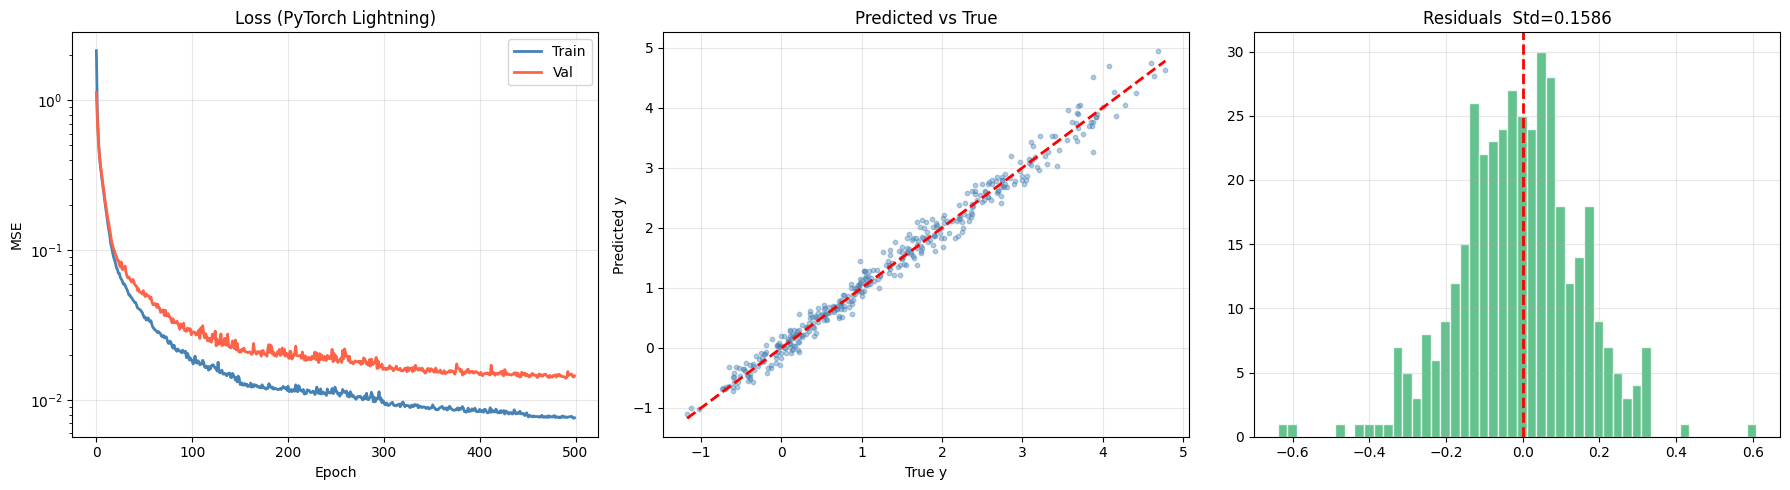

R²  : 0.9853
MAE : 0.1232
RMSE: 0.1590


In [6]:
# ─────────────────────────────────────────────
# SECTION 6: Results
# ─────────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(model.train_losses, label='Train', color='steelblue', lw=2)
axes[0].plot(model.val_losses,   label='Val',   color='tomato',    lw=2)
axes[0].set_yscale('log')
axes[0].set_title('Loss (PyTorch Lightning)')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('MSE')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

model.eval()
X_test_t = torch.from_numpy(X_te)
with torch.no_grad():
    y_pred_np = model(X_test_t).numpy()

y_true_d = y_te * y_std + y_mean
y_pred_d = y_pred_np * y_std + y_mean

axes[1].scatter(y_true_d, y_pred_d, alpha=0.4, s=10, color='steelblue')
lims = [y_true_d.min(), y_true_d.max()]
axes[1].plot(lims, lims, 'r--', lw=2)
axes[1].set_title('Predicted vs True'); axes[1].grid(True, alpha=0.3)
axes[1].set_xlabel('True y'); axes[1].set_ylabel('Predicted y')

resid = (y_true_d - y_pred_d).ravel()
axes[2].hist(resid, bins=50, color='mediumseagreen', edgecolor='white', alpha=0.8)
axes[2].axvline(0, color='red', linestyle='--', lw=2)
axes[2].set_title(f'Residuals  Std={resid.std():.4f}')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('colab_d_results.png', dpi=120, bbox_inches='tight')
plt.show()

print(f'R²  : {r2_score(y_true_d, y_pred_d):.4f}')
print(f'MAE : {mean_absolute_error(y_true_d, y_pred_d):.4f}')
print(f'RMSE: {np.sqrt(np.mean(resid**2)):.4f}')